In [ ]:
### Required libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_fourier_slice.slice_insertion._insert_central_slices_rfft_3d import (
    insert_central_slices_rfft_3d,
)
from torch_ctf import *


In [53]:
pip install mrcfile

Note: you may need to restart the kernel to use updated packages.


In [43]:
def generate_sphere(box_size, sphere_radius, pixel_size, edge_width=0.7):
    """
    Sphere with a soft (sigmoid) edge.
 
    edge_width : edge softness in voxels (~0.5-1 is enough). 0 -> the old hard-edged binary sphere.
 
    The old binary sphere (dist^2 <= r^2, centre 32.0, r = 8) has six isolated one-voxel tips at the
    poles, because the distance on the axes is exactly 8. Those tips act like delta functions and show
    up as bright spots after the missing-wedge filter. The soft edge removes them.
    The centre stays at grid_dim/2, which is the origin of the fftshift'ed Fourier grid.
    """
    grid_dim = int(box_size // pixel_size)
    center_idx = (box_size / 2.0) / pixel_size
    radius_idx = sphere_radius / pixel_size
 
    z, y, x = np.ogrid[:grid_dim, :grid_dim, :grid_dim]
    dist = np.sqrt((x - center_idx) ** 2 + (y - center_idx) ** 2 + (z - center_idx) ** 2)
 
    if edge_width <= 0:
        return (dist <= radius_idx).astype(np.float32)
    return (1.0 / (1.0 + np.exp((dist - radius_idx) / edge_width))).astype(np.float32)


def get_missing_wedge_mask(grid_size, mw_angle, device="cpu"):
    """
    Produces a 3D binary mask with shape 'grid_size', which can be used to zero-out Fourier components that lie inside a missing wedge with width 'mw_angle'.
    """
    grid = get_3d_fft_freqs_on_grid(grid_size=grid_size, device=device)

    # make normal vectors of two hyperplanes that bound the missing wedge
    alpha = torch.deg2rad(torch.tensor(float(mw_angle), device=device)) / 2
    normal_left = torch.tensor([torch.sin(alpha), torch.cos(alpha)], device=device)
    normal_right = torch.tensor([torch.sin(alpha), -torch.cos(alpha)], device=device)

    # embed normal vectors into the x-z plane
    normal_left = torch.tensor([normal_left[0], 0.0, normal_left[1]], device=device)
    normal_right = torch.tensor([normal_right[0], 0.0, normal_right[1]], device=device)

    # select points that lie inside the missing wedge
    grid_size = [int(s) for s in grid_size]
    upper_wedge = torch.logical_or(
        grid.inner(normal_left) >= 0, grid.inner(normal_right) >= 0
    ).reshape(list(grid_size))
    lower_wedge = torch.logical_or(
        grid.inner(normal_left) <= 0, grid.inner(normal_right) <= 0
    ).reshape(list(grid_size))

    # the missing-wedge region is where both inequalities are satisfied
    mw_mask = torch.logical_and(upper_wedge, lower_wedge).to(torch.float32)

    # keep the valid Fourier components, but do not remove the origin/DC term
    keep_mask = 1.0 - mw_mask
    keep_mask[grid_size[0] // 2, grid_size[1] // 2, grid_size[2] // 2] = 1.0

    return keep_mask


def get_3d_fft_freqs_on_grid(grid_size, device="cpu"):
    """
    Produces a 3D tensor with shape 'grid_size' whose entries are the spatial frequencies that correspond to the entries of a fourier transform computed with 'fft_3d'.
    """
    z = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[0]), device=device))
    y = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[1]), device=device))
    x = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[2]), device=device))
    grid = torch.cartesian_prod(z, y, x)
    return grid


In [44]:
# Obtain sphere data

box_size = 64
perfect_data = generate_sphere(box_size=box_size, sphere_radius=8, pixel_size=1)

ctf_values = {
    "defocus": 3,  # in micrometers
    "astigmatism": 0.0,  # in micrometers
    "astigmatism_angle": 0.0,  # in degrees
    "voltage": 200,  # in volts
    "spherical_aberration": 2.7, # mm float | torch.Tensor,
    "amplitude_contrast": 0.07, # float | torch.Tensor,
    "phase_shift": 0.0, # float | torch.Tensor,
    "pixel_size": 10, # float | torch.Tensor,
    "image_shape": (box_size, box_size), # tuple[int, int],
    "rfft": True, # bool,
    "fftshift": True, # bool,
    "beam_tilt_mrad": None, # torch.Tensor | None = None,
    "even_zernike_coeffs": None, # dict | None = None,
    "odd_zernike_coeffs": None, # dict | None = None,
    "transform_matrix": None, # torch.Tensor | None = None,
    "return_complex_ctf": False, # bool = False, 
}

In [45]:
def plot_3d_data(data, threshold=None, percentile=95, grey_scale=False):
    """
    Plot voxels of a continuous 3D field above a threshold.
    If threshold is None, it's set automatically using `percentile`
    (e.g. top 5% of intensity values).
    """
    if threshold is None:
        threshold = np.percentile(data, percentile)

    x, y, z = np.where(data >= threshold)
    values = data[x, y, z]

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    if grey_scale:
        sc = ax.scatter(x, y, z, c=values, cmap='gray_r', s=2, alpha=0.3)
    else:
        sc = ax.scatter(x, y, z, c=values, cmap='viridis', s=2)
    fig.colorbar(sc, ax=ax, shrink=0.6, label='Intensity')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim(0, data.shape[0])
    ax.set_ylim(0, data.shape[1])
    ax.set_zlim(0, data.shape[2])
    ax.set_title(f'Voxels above threshold={threshold:.3f}')

    plt.show()


def plot_slice(data, axis=0, index=None, threshold=None, percentile=95):
    """
    Plot a 2D slice of a 3D field along the specified axis.
    If index is None, the middle slice is plotted.
    If threshold is None, it's set automatically using `percentile`
    (e.g. top 5% of intensity values).
    """
    if index is None:
        index = data.shape[axis] // 2

    if threshold is None:
        threshold = np.percentile(data, percentile)

    if axis == 0:
        slice_data = data[index, :, :]
    elif axis == 1:
        slice_data = data[:, index, :]
    elif axis == 2:
        slice_data = data[:, :, index]
    else:
        raise ValueError("Axis must be 0, 1, or 2.")

    plt.figure()
    plt.imshow(slice_data.T, origin='lower', cmap='gray', vmin=0, vmax=np.max(slice_data))
    plt.colorbar(label='Intensity')
    plt.title(f'Slice along axis {axis} at index {index} (threshold={threshold:.3f})')
    plt.xlabel('X-axis' if axis != 0 else 'Y-axis')
    plt.ylabel('Y-axis' if axis != 1 else 'Z-axis')
    plt.show()

In [46]:
def rotation_matrix_y(angle_deg, device="cpu"):
    theta = torch.deg2rad(torch.tensor(float(angle_deg), device=device))
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.stack([
        torch.stack([ c, torch.tensor(0.0, device=device),  s]),
        torch.stack([ torch.tensor(0.0, device=device), torch.tensor(1.0, device=device), torch.tensor(0.0, device=device)]),
        torch.stack([-s, torch.tensor(0.0, device=device),  c]),
    ])

def get_slice_inserted_wedge(volume_shape, mw_angle, tilt_step=2.0, ctf_values=None, device="cpu"):
    box = volume_shape[0]
    
    # Add offset adjustment to map [-135, -45] accurately to the slice plane
    target_start = -mw_angle - 90  # e.g., -45 - 90 = -135
    target_end = -mw_angle         # e.g., -45
    
    # Offset by +45 degrees to align the 2D plane normal with the target wedge angle
    tilt_angles = torch.arange(
        target_start + 45.0, 
        target_end + 45.0 + tilt_step, 
        tilt_step, device=device
    )
    # print(f"Tilt angles: {tilt_angles}")

    images = torch.ones((len(tilt_angles), box, box//2 + 1), dtype=torch.float32, device=device)

    if ctf_values is not None:
        ctf_image = calculate_ctf_2d(
            defocus=ctf_values["defocus"],
            astigmatism=ctf_values["astigmatism"],
            astigmatism_angle=ctf_values["astigmatism_angle"],
            voltage=ctf_values["voltage"],
            spherical_aberration=ctf_values["spherical_aberration"],
            amplitude_contrast=ctf_values["amplitude_contrast"],
            phase_shift=ctf_values["phase_shift"],
            pixel_size=ctf_values["pixel_size"],
            image_shape=ctf_values["image_shape"],
            rfft=ctf_values["rfft"],
            fftshift=ctf_values["fftshift"],
            beam_tilt_mrad=ctf_values["beam_tilt_mrad"],
            even_zernike_coeffs=ctf_values["even_zernike_coeffs"],
            odd_zernike_coeffs=ctf_values["odd_zernike_coeffs"],
            transform_matrix=ctf_values["transform_matrix"],
            return_complex_ctf=ctf_values["return_complex_ctf"]
        )
        images = torch.stack([ctf_image] * len(tilt_angles))

    rotation_matrices = torch.stack([rotation_matrix_y(a, device=device) for a in tilt_angles])

    dft, weights = insert_central_slices_rfft_3d(
        image_rfft=images,
        volume_shape=volume_shape,
        rotation_matrices=rotation_matrices,
        zyx_matrices=False,
    )

    def _negate_freq_index(n, device):
        return (n - torch.arange(n, device=device)) % n

    D, H, Wh = weights.shape
    device = weights.device
    half = box // 2

    full = torch.zeros((D, H, box), dtype=weights.dtype, device=device)

    # positive-x half (incl. DC): same z, y -> direct copy
    full[:, :, half:] = weights[:, :, :-1]

    # negative-x half: needs z AND y negated too, not just x mirrored
    z_neg = _negate_freq_index(D, device)
    y_neg = _negate_freq_index(H, device)
    mirrored_source = weights[z_neg][:, y_neg][..., 1:]     # i = 1..half
    full[:, :, :half] = torch.flip(mirrored_source, dims=(-1,))
    full_weights = full / torch.max(full)

    full_dft = torch.zeros((D, H, box), dtype=dft.dtype, device=device)
    full_dft[:, :, half:] = dft[:, :, :-1]
    mirrored_dft = torch.conj(dft[z_neg][:, y_neg][..., 1:])
    full_dft[:, :, :half] = torch.flip(mirrored_dft, dims=(-1,))

    return full_dft, full_weights

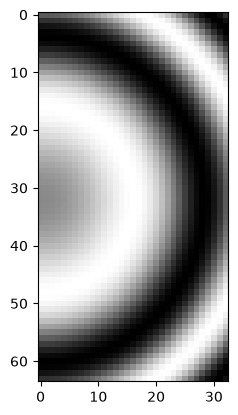

In [47]:
ctf_image = calculate_ctf_2d(
            defocus=ctf_values["defocus"],
            astigmatism=ctf_values["astigmatism"],
            astigmatism_angle=ctf_values["astigmatism_angle"],
            voltage=ctf_values["voltage"],
            spherical_aberration=ctf_values["spherical_aberration"],
            amplitude_contrast=ctf_values["amplitude_contrast"],
            phase_shift=ctf_values["phase_shift"],
            pixel_size=ctf_values["pixel_size"],
            image_shape=ctf_values["image_shape"],
            rfft=ctf_values["rfft"],
            fftshift=ctf_values["fftshift"],
            beam_tilt_mrad=ctf_values["beam_tilt_mrad"],
            even_zernike_coeffs=ctf_values["even_zernike_coeffs"],
            odd_zernike_coeffs=ctf_values["odd_zernike_coeffs"],
            transform_matrix=ctf_values["transform_matrix"],
            return_complex_ctf=ctf_values["return_complex_ctf"]
        )
plt.imshow(ctf_image.numpy(), cmap='gray')

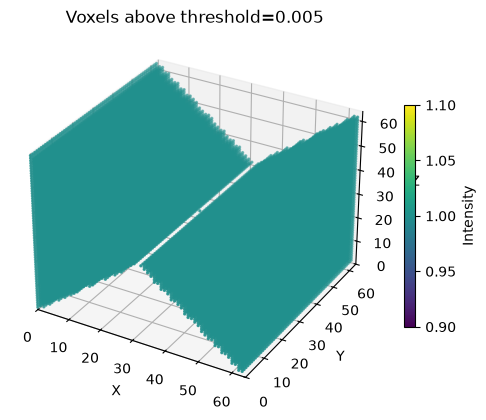

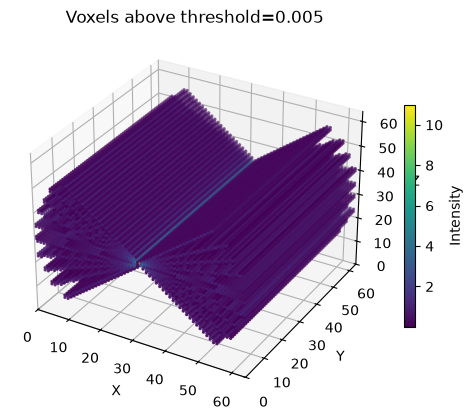

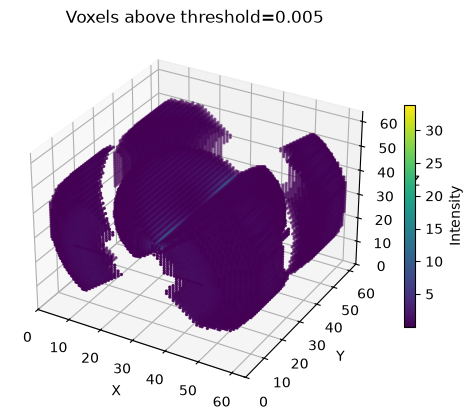

In [ ]:
# create wedge_models

# create DeepDeWedge missing wedge mask
binary_missing_wedge = get_missing_wedge_mask(grid_size=perfect_data.shape, mw_angle=90, device="cpu").numpy()
plot_3d_data(binary_missing_wedge, threshold=0.005)

# create slice inserted wedge with the help of teamtomo
slice_inserted_wedge, _ = get_slice_inserted_wedge(volume_shape=perfect_data.shape, mw_angle=90, tilt_step=10, ctf_values=None, device="cpu")
plot_3d_data(slice_inserted_wedge, threshold=0.005)

# Insert the 2D CTF slices; the first return value is the CTF-weighted Fourier volume.
d_ctf, _ = get_slice_inserted_wedge(volume_shape=perfect_data.shape, mw_angle=90, tilt_step=3, ctf_values=ctf_values, device="cpu")
plot_3d_data(d_ctf.numpy(), threshold=0.005, grey_scale=False)
masks = [binary_missing_wedge, slice_inserted_wedge, d_ctf]



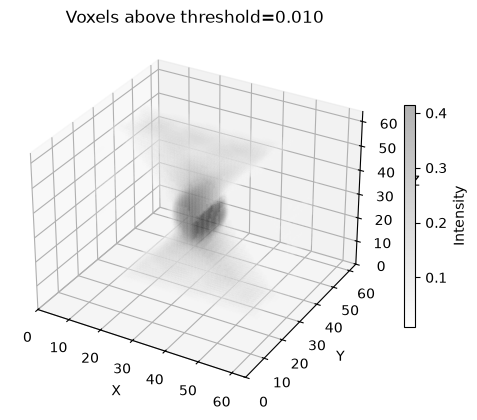

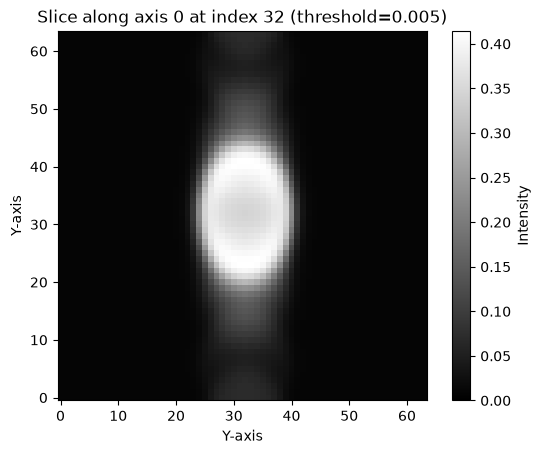

In [55]:
perfect_data_fft = torch.fft.fftshift(torch.fft.fftn(torch.Tensor(perfect_data)))
mask_t = torch.as_tensor(binary_missing_wedge, dtype=perfect_data_fft.dtype)

convolved = torch.fft.ifftn(torch.fft.ifftshift(perfect_data_fft * mask_t))
convolved_real = convolved.real.numpy()

plot_3d_data(convolved_real, threshold=0.01, percentile=95, grey_scale=True)
plot_slice(convolved_real, axis=0, index=box_size // 2, threshold=0.005)

In [50]:
print((d_ctf - slice_inserted_wedge).numpy().sum())


6743.050625846203


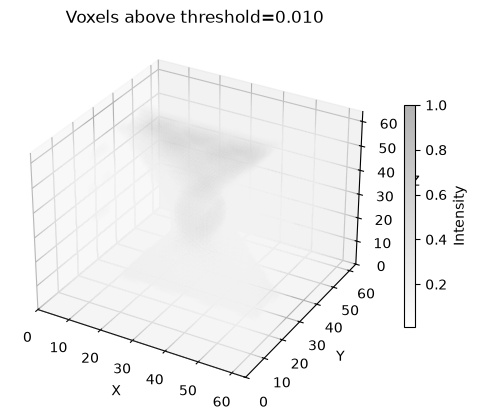

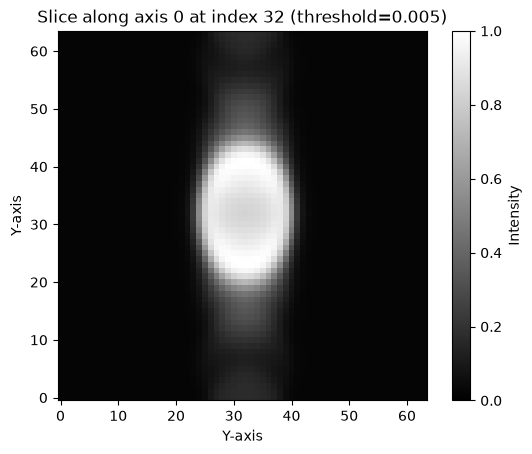

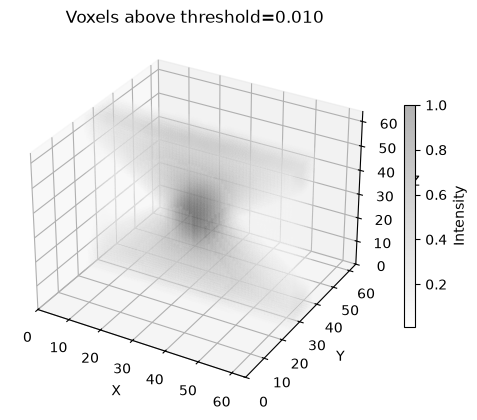

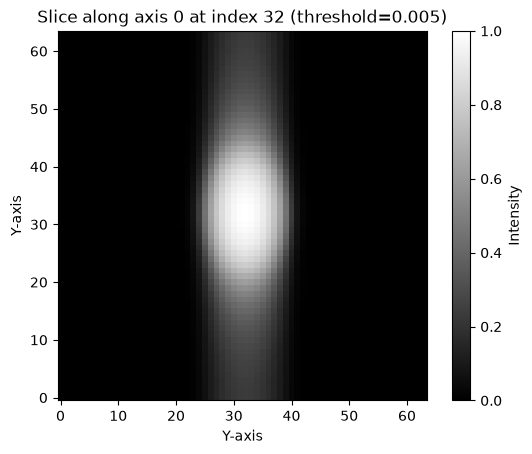

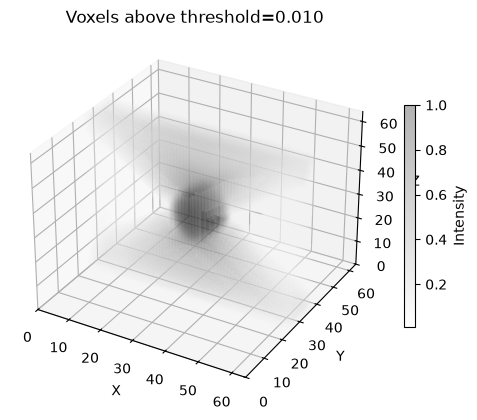

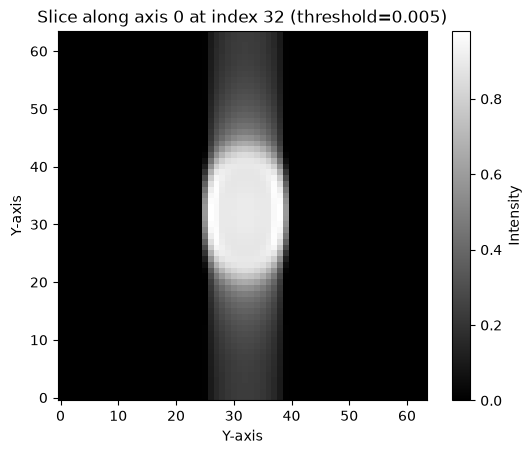

In [58]:
# Apply fftn to sphere data
perfect_data_fft = torch.fft.fftshift(torch.fft.fftn(torch.Tensor(perfect_data)))

for mask in masks:
    mask_t = torch.as_tensor(mask, dtype=perfect_data_fft.dtype)
    convolved = torch.fft.ifftn(torch.fft.ifftshift(perfect_data_fft * mask_t))
    convolved_real = convolved.real.numpy() / np.max(convolved.real.numpy())  # Normalize to [0, 1]

    plot_3d_data(convolved_real, threshold=0.01, percentile=95, grey_scale=True)
    plot_slice(convolved_real, axis=0, index=box_size//2, threshold=0.005)

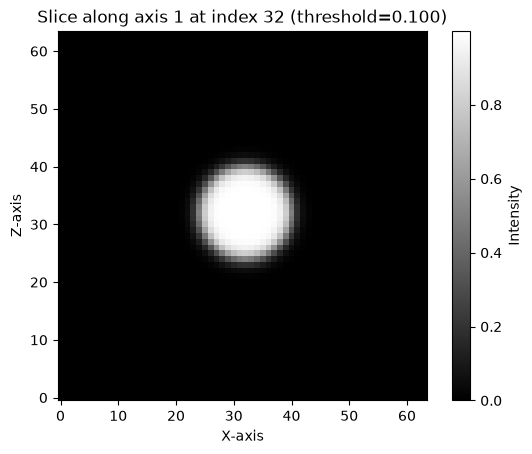

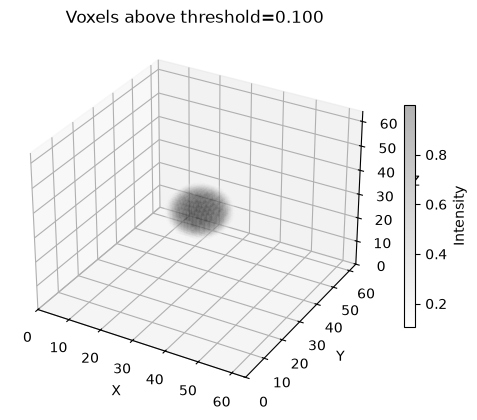

In [52]:
plot_slice(perfect_data, axis=1, index=32, threshold=0.1)
plot_3d_data(perfect_data, threshold=0.1, percentile=95, grey_scale=True)